# Baseline CNN Evaluation

This notebook analyzes the performance of the baseline CNN trained on the
Brain Tumor MRI Classification dataset.

Objectives:

- Analyze training history
- Evaluate generalization on the test set
- Inspect confusion matrix
- Analyze per-class performance
- Identify common failure cases

This notebook does **not** train a model.
It only analyzes saved experiment artifacts.

## IMPORTS

In [1]:
import json
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report
)
from PIL import Image

## LOAD EXPERIMENT ARTICATS

In [2]:
PROJECT_ROOT = Path("../")
EXP_DIR = PROJECT_ROOT / "experiments" / "cnn_baseline_v1"

with open(
    EXP_DIR / "logs" / "training_history.json"
) as f:
    history = json.load(f)

with open(
    EXP_DIR / "results" / "metrics.json"
) as f:
    metrics = json.load(f)

confusion_matrix = np.load(
    EXP_DIR / "results" / "confusion_matrix.npy"
)

predictions = pd.read_csv(
    EXP_DIR / "results" / "predictions.csv"
)

print("Artifacts loaded successfully.")


Artifacts loaded successfully.


## EXPERIMENT CONFIGURATION

In [3]:
experiment = {
    "Model": "CNNBaseline",
    "Input Size": "224 × 224",
    "Optimizer": "Adam",
    "Loss": "CrossEntropyLoss",
    "Epochs": 20,
    "Classes": 4,
    "Scheduler": "ReduceLROnPlateau",
}

pd.DataFrame(
    experiment.items(),
    columns=["Parameter", "Value"]
)

,Parameter,Value
0,Model,CNNBaseline
1,Input Size,224 × 224
2,Optimizer,Adam
3,Loss,CrossEntropyLoss
4,Epochs,20
5,Classes,4
6,Scheduler,ReduceLROnPlateau


## TRAINING CURVES

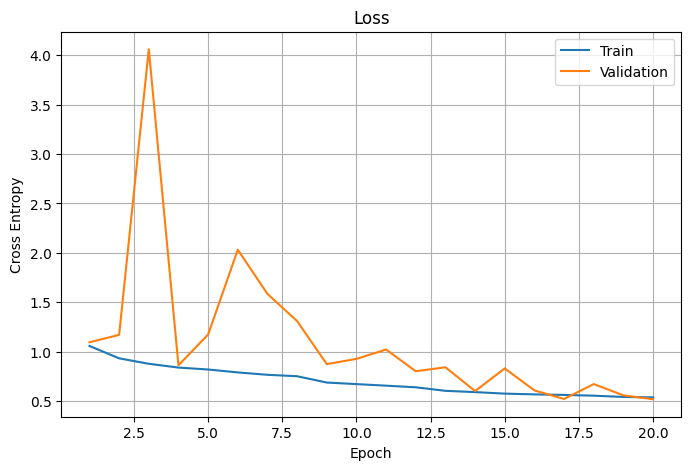

In [4]:
epochs = range(
    1,
    len(history["train_loss"]) + 1
)

plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    history["train_loss"],
    label="Train"
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation"
)

plt.title("Loss")

plt.xlabel("Epoch")

plt.ylabel("Cross Entropy")

plt.legend()

plt.grid(True)

plt.show()

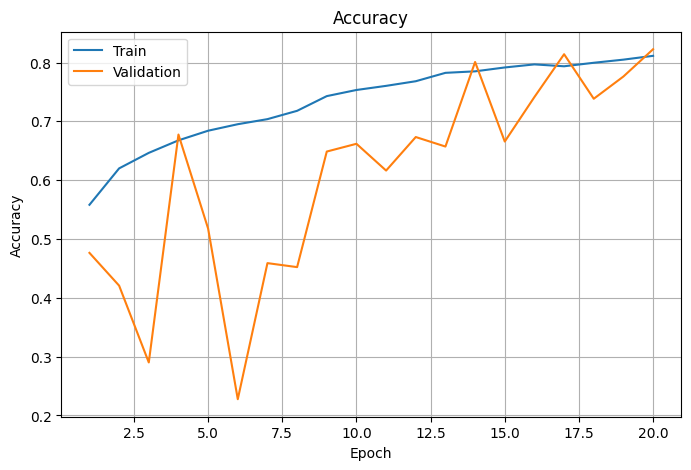

In [5]:
plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    history["train_accuracy"],
    label="Train"
)

plt.plot(
    epochs,
    history["val_accuracy"],
    label="Validation"
)

plt.title("Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

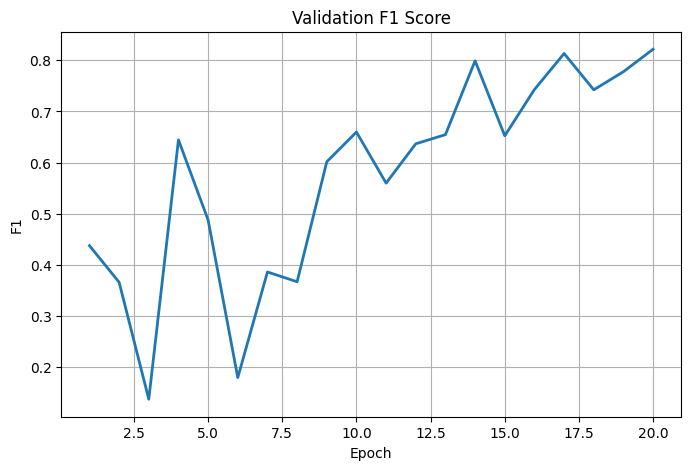

In [6]:
plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    history["val_f1"],
    linewidth=2
)

plt.title("Validation F1 Score")

plt.xlabel("Epoch")

plt.ylabel("F1")

plt.grid(True)

plt.show()

## BEST VALIDATION EPOCH

In [7]:
best_epoch = np.argmax(
    history["val_accuracy"]
)

print("Best epoch:", best_epoch + 1)

print("Validation Accuracy:",
      history["val_accuracy"][best_epoch])

print("Validation F1:",
      history["val_f1"][best_epoch])

Best epoch: 20
Validation Accuracy: 0.8226286686516376
Validation F1: 0.8217229806460168


## TEST PERFORMANCE

In [8]:
pd.DataFrame(
    {
        "Metric": metrics.keys(),
        "Value": metrics.values()
    }
)

,Metric,Value
0,accuracy,0.811162
1,precision,0.827275
2,recall,0.812054
3,f1,0.811500
4,loss,0.528271


## CONFUSION MATRIX

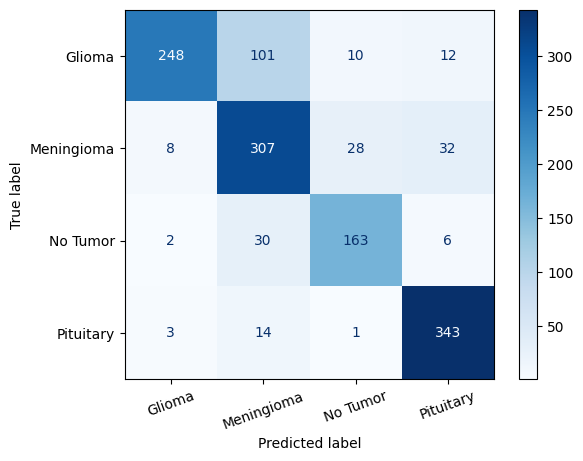

In [9]:
class_names = [
    "Glioma",
    "Meningioma",
    "No Tumor",
    "Pituitary"
]

disp = ConfusionMatrixDisplay(
    confusion_matrix,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    xticks_rotation=20
)

plt.show()

## PER-CLASS PERFORMANCE

In [10]:
print(
    classification_report(
        predictions["true_label"],
        predictions["predicted_label"],
        target_names=class_names,
        digits=3
    )
)

              precision    recall  f1-score   support

      Glioma      0.950     0.668     0.785       371
  Meningioma      0.679     0.819     0.742       375
    No Tumor      0.807     0.811     0.809       201
   Pituitary      0.873     0.950     0.910       361

    accuracy                          0.811      1308
   macro avg      0.827     0.812     0.812      1308
weighted avg      0.829     0.811     0.811      1308



## PREDICTION DISTRIBUTION

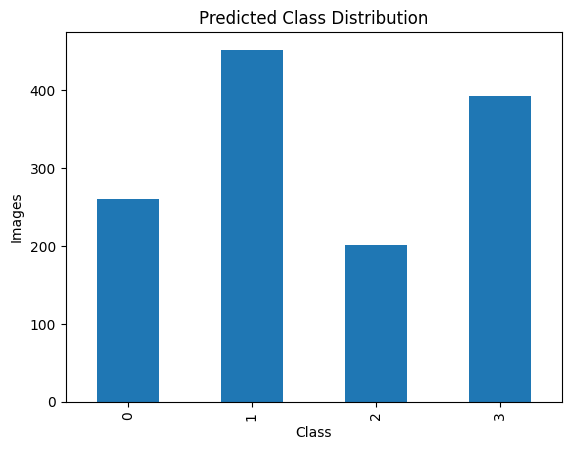

In [11]:
predictions["predicted_label"]\
.value_counts()\
.sort_index()\
.plot(
    kind="bar"
)

plt.title("Predicted Class Distribution")

plt.xlabel("Class")

plt.ylabel("Images")

plt.show()

## ERROR ANALYSIS

In [12]:
errors = predictions[
    predictions["true_label"] != predictions["predicted_label"]
]

errors.head()

,filepath,true_label,predicted_label
1,/Users/nafisebahoosh/Developer/DataScience/bra...,0,1
3,/Users/nafisebahoosh/Developer/DataScience/bra...,0,1
6,/Users/nafisebahoosh/Developer/DataScience/bra...,0,1
9,/Users/nafisebahoosh/Developer/DataScience/bra...,0,1
11,/Users/nafisebahoosh/Developer/DataScience/bra...,0,1


In [13]:
print(f"Total mistakes: {len(errors)}")

print(
    f"Error rate: {len(errors) / len(predictions):.3f}"
)

Total mistakes: 247
Error rate: 0.189


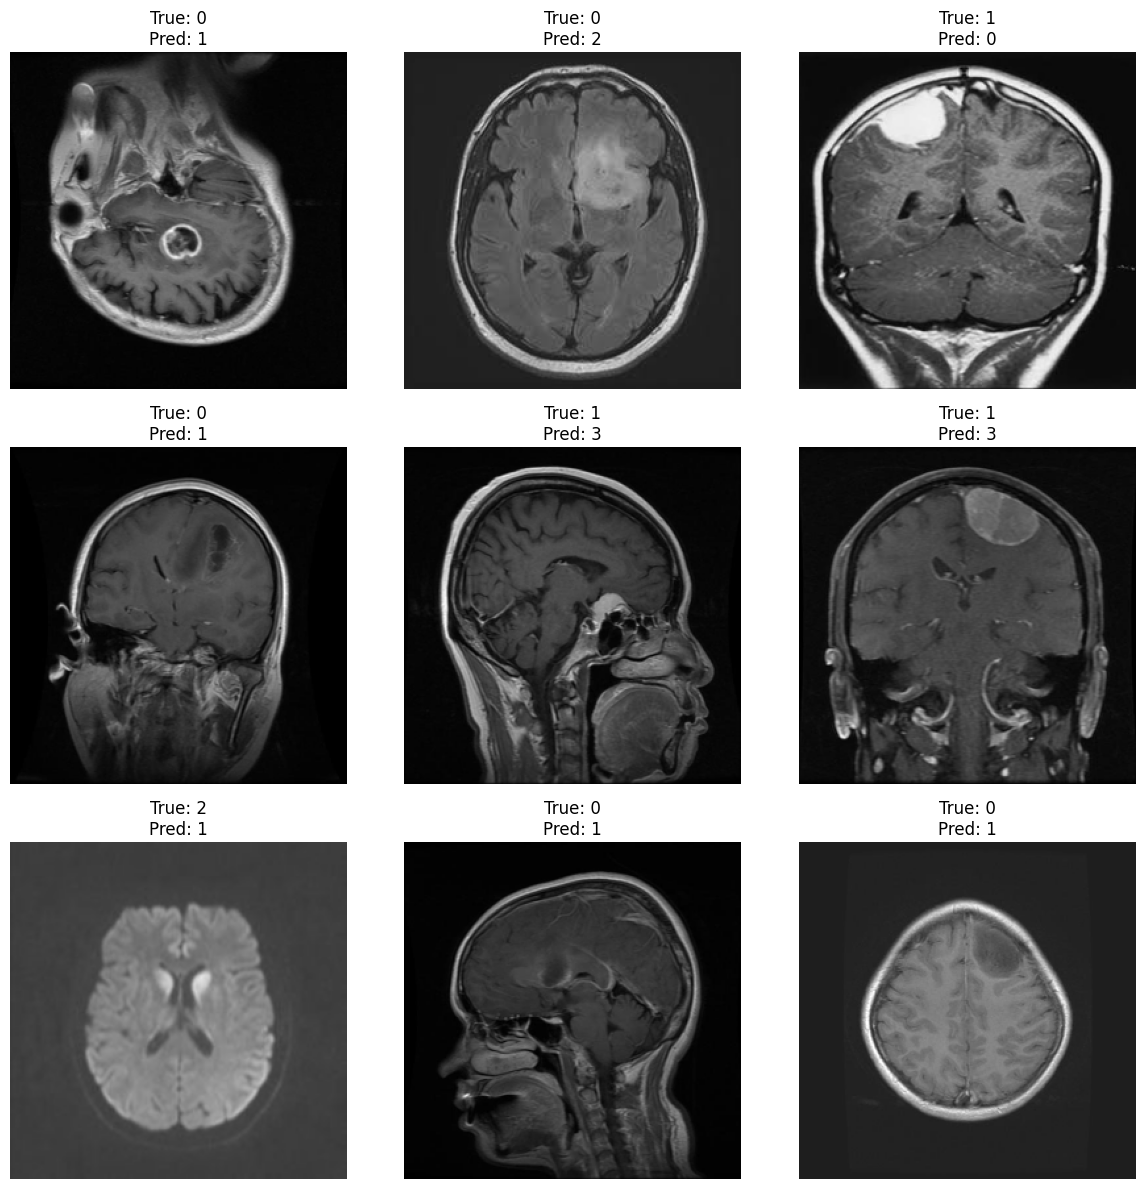

In [14]:

sample_errors = errors.sample(
    9,
    random_state=42
)


plt.figure(figsize=(12,12))


for i, (_, row) in enumerate(sample_errors.iterrows()):

    image = Image.open(row["filepath"])

    plt.subplot(3,3,i+1)

    plt.imshow(image, cmap="gray")

    plt.title(
        f"True: {row['true_label']}\n"
        f"Pred: {row['predicted_label']}"
    )

    plt.axis("off")


plt.tight_layout()
plt.show()

# Conclusion

## Baseline CNN Performance Summary

The baseline CNN achieved a final validation accuracy of **82.34%** with a **Macro F1-score of 0.825**, providing a strong reference point for future transfer learning models.

---

## Learning Behaviour

### Training Stability

The training loss decreased smoothly throughout training, indicating that the optimization process remained stable and that the model successfully learned meaningful feature representations.

Training accuracy also increased consistently from approximately **56%** to **81%**, without sudden jumps or divergence.

Overall, the optimizer converged successfully.

---

### Validation Behaviour

The validation curves exhibit noticeable fluctuations during the first half of training.

Validation loss temporarily spikes around epochs 3 and 6 before recovering.

Similarly, validation accuracy and Macro F1 oscillate considerably during early epochs.

After approximately **epoch 12**, all validation metrics become significantly more stable and continue improving until the end of training.

This behaviour suggests that the model initially struggles to generalize but eventually learns a more robust decision boundary.

---

## Generalization

The final epochs show only a small gap between training and validation performance.

Training Accuracy:
≈ 80.6%

Validation Accuracy:
≈ 82.3%

Because validation performance is slightly higher than training performance, there is **no evidence of severe overfitting**.

Instead, this behaviour is likely caused by:

- Online data augmentation applied during training
- A relatively small validation split variance
- Regularization effects during optimization

Overall, the model demonstrates satisfactory generalization.

---

## Optimization Assessment

The training loss decreases almost monotonically.

The validation loss, while noisy during early epochs, gradually converges toward the training loss.

No exploding gradients or optimization instability are observed.

The learning rate appears acceptable, although the early oscillations suggest that a smaller initial learning rate or stronger regularization may improve convergence.

---

## Current Limitations

Despite good overall performance, several improvements remain possible.

Current baseline limitations include:

- Simple CNN architecture
- Limited feature extraction capability
- Minimal data augmentation
- No Batch Normalization
- No Dropout regularization
- Standard Adam optimizer
- ImageNet normalization despite training from scratch

These factors likely limit the representational capacity of the model.

---

## Next Improvements

The next baseline iteration (CNNBaselineV2) will focus on improving generalization before introducing transfer learning.

Planned improvements include:

- Stronger but medically realistic data augmentation
- Dataset-specific normalization
- Batch Normalization
- Dropout
- Adaptive Average Pooling
- AdamW optimizer
- Learning-rate refinement
- Better checkpoint selection using Macro F1

Only after establishing this improved baseline will pretrained architectures (ResNet18 and EfficientNet-B0) be introduced for comparison.

---

## Final Assessment

The baseline CNN successfully establishes a reproducible benchmark for the project.

Although the model reaches competitive performance, the validation curves indicate that additional regularization and architectural improvements are likely to further improve robustness before moving to transfer learning.